# Fonte dos dados 

https://archive.ics.uci.edu/dataset/14/breast+cancer

# Categorização, Codificação e Binarização de Variáveis com SQL

# CATEGORIZACAO

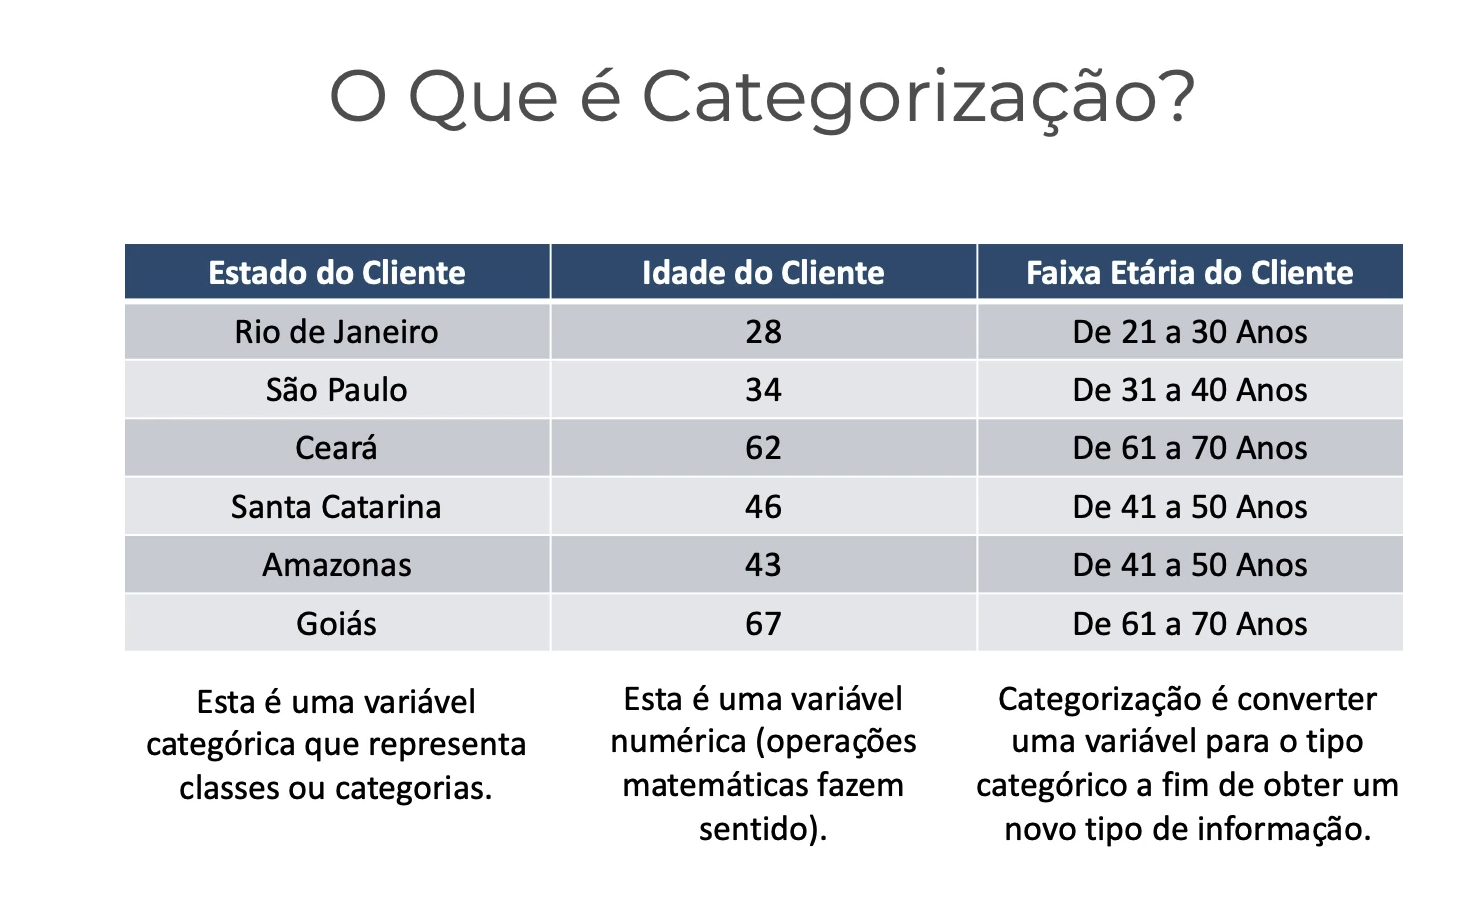

# CODIFICACAO (Label-encoding) 

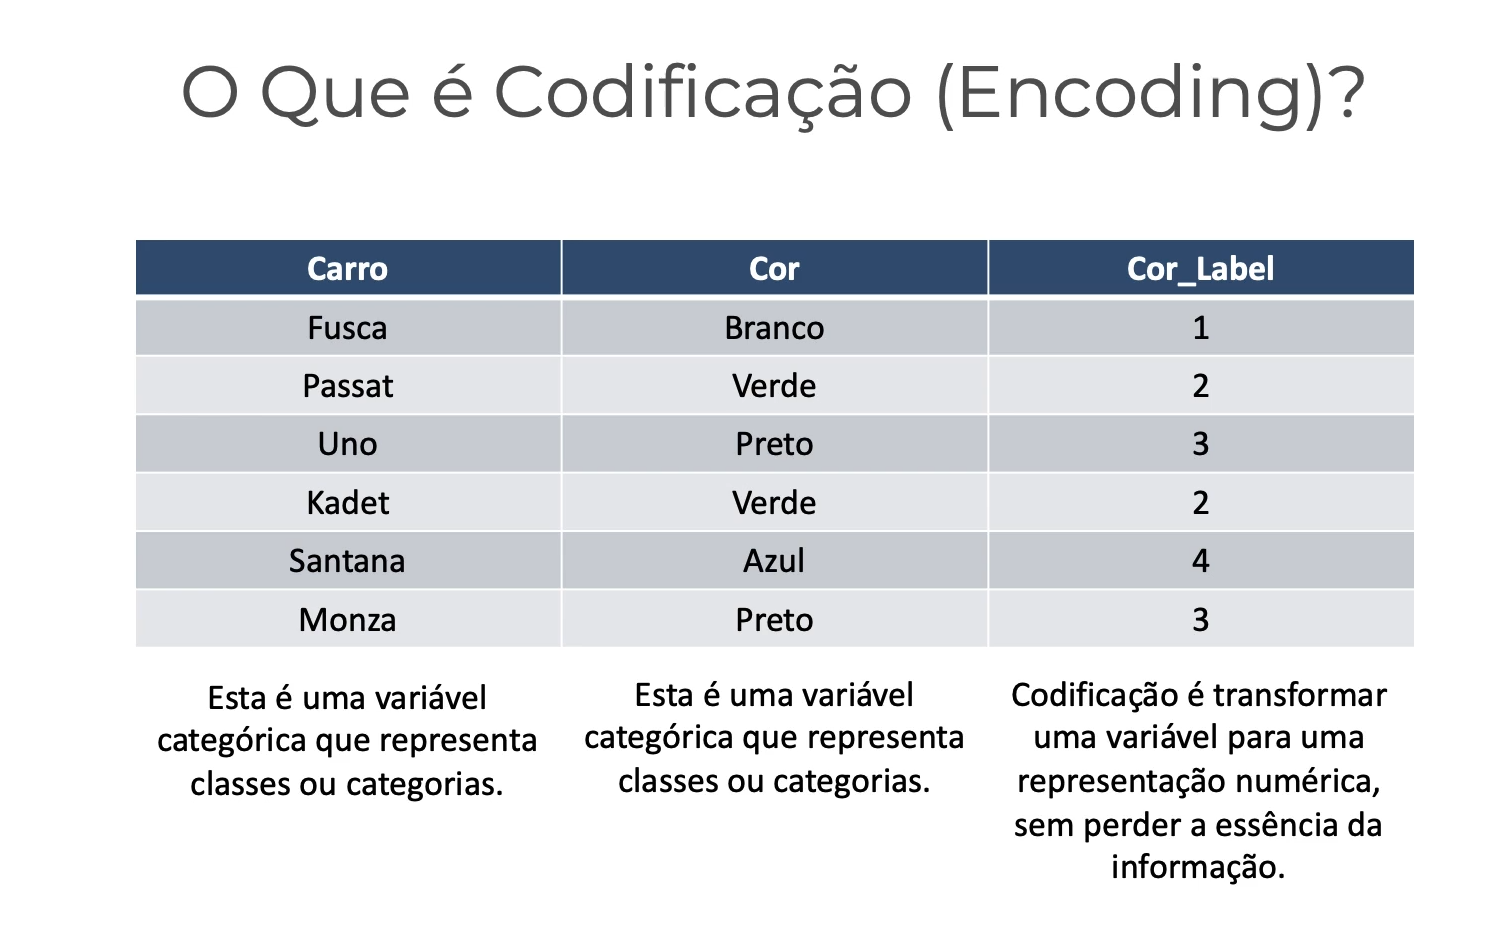

# ONE HOT ENCODING

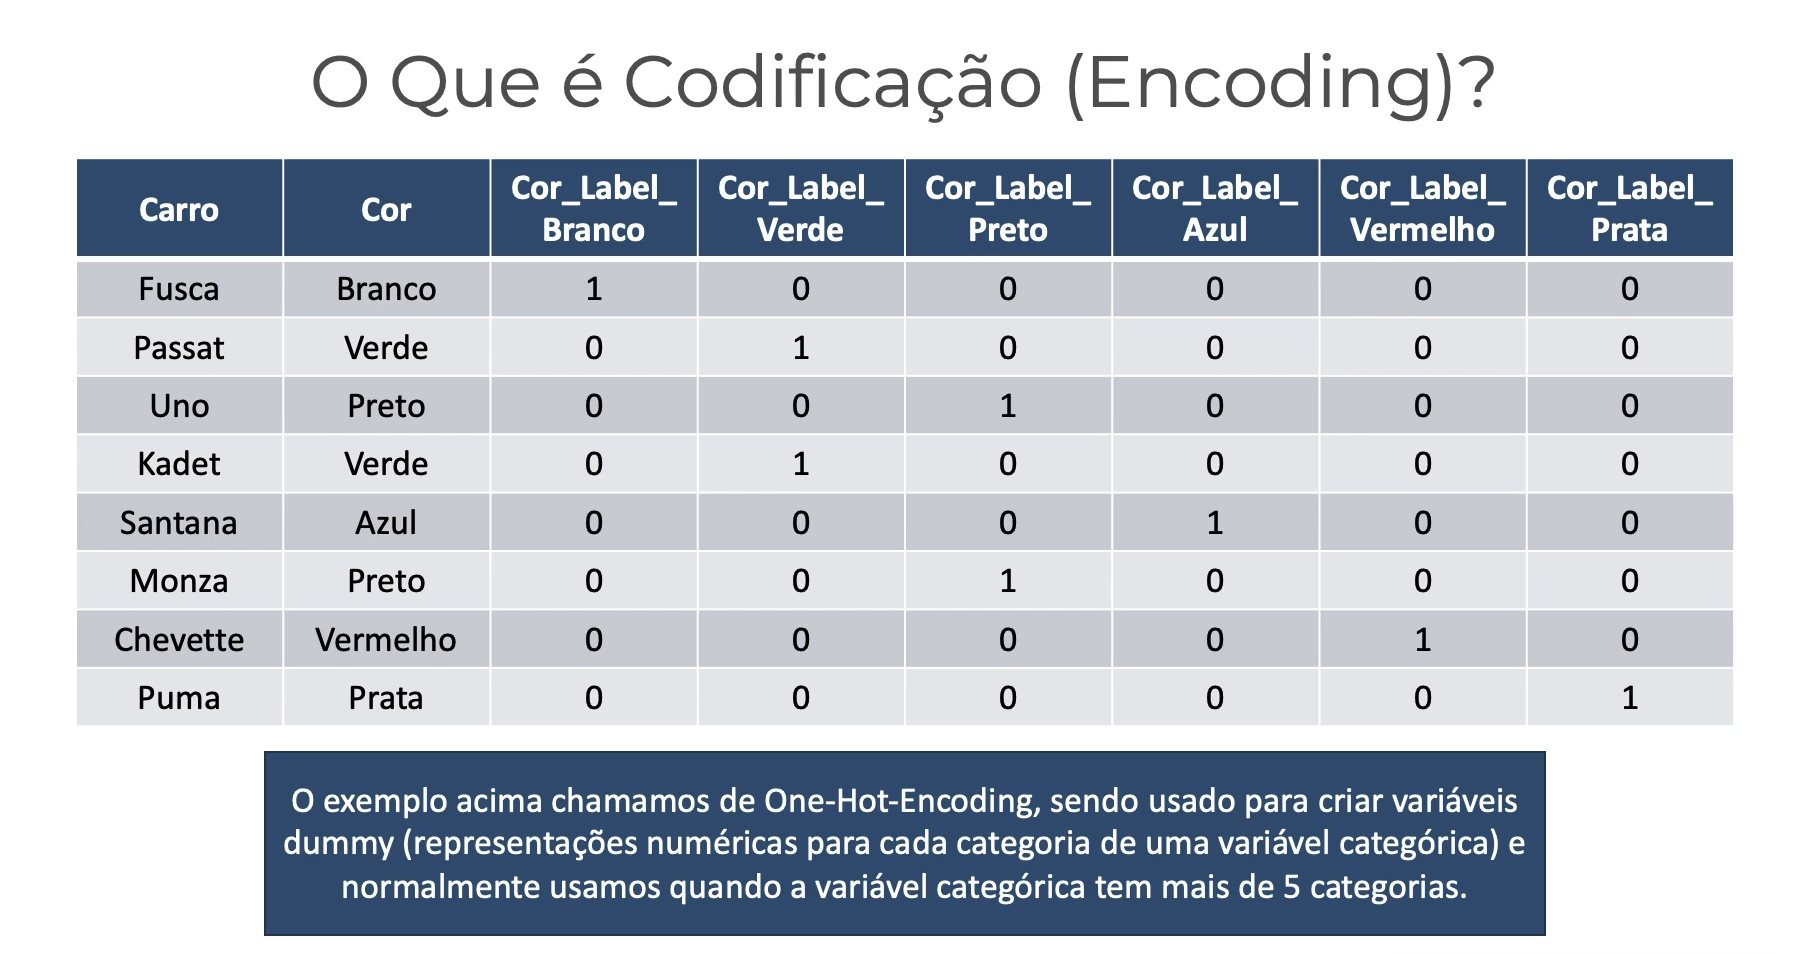

# BINARIZACAO

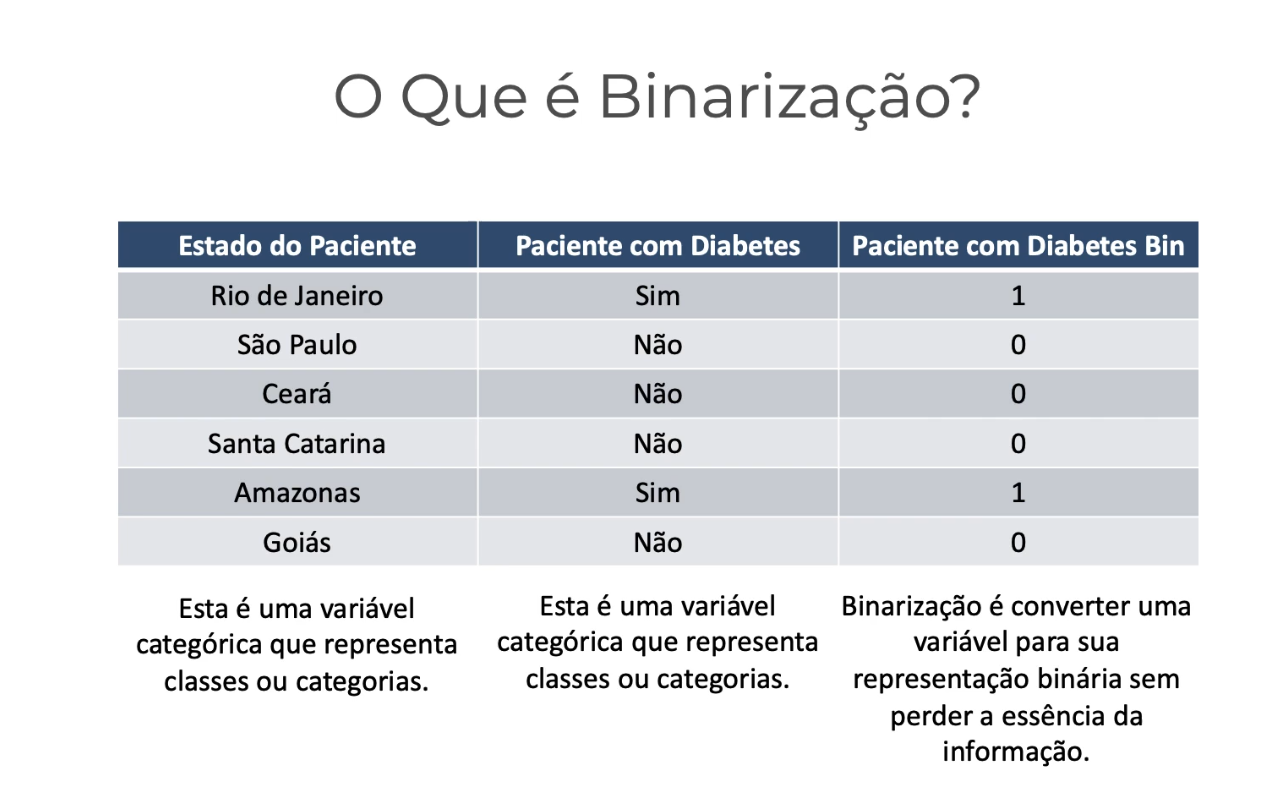

# BINARIZACAO - Transforma um texto em O / 1 

In [ ]:
#BINARIZACAO DA VARIAVEL CLASSE (0/1)

SELECT DISTINCT classe FROM tb_cancer;

SELECT 
    CASE
        WHEN classe = 'no-recurrence-events' THEN 0 
        WHEN classe = 'recurrence-events' THEN 1 
    END as classe
FROM tb_cancer;

In [ ]:
#BINARIZACAO DA VARIAVEL IRRADIANDO (0/1)

SELECT DISTINCT irradiando FROM tb_cancer;

SELECT 
    CASE
        WHEN classe = 'no' THEN 0 
        WHEN classe = 'yes' THEN 1 
    END as irradiando
FROM tb_cancer;

In [ ]:
#BINARIZACAO DA VARIAVEL node-caps (0/1)

# a coluna node_caps tem um terceiro valor, que é uma ''?'', entao temos, yes, no e ''?''
# como temos 3 valores possiveis, virou um label encoding e não mais binarização

SELECT DISTINCT node_caps FROM tb_cancer;

SELECT 
    CASE
        WHEN node_caps = 'no' THEN 0 
        WHEN node_caps = 'yes' THEN 1 
        ELSE 2
    END as node_caps
FROM tb_cancer;

# CATEGORIZAÇÃO- DÁ UMA CATEGORIA A UM TEXTO OU INTERVALO DE COISAS

In [ ]:
# CATEGORIZACAO DA VARIAVEL SEIO (E/D)

SELECT DISTINCT seio FROM tb_cancer;

SELECT 
    CASE
        WHEN seio = 'left'THEN 'E' 
        WHEN seio = 'right' THEN 'D' 
    END as seio
FROM tb_cancer;


In [ ]:
# CATEGORIZACAO DA VARIAVEL tamanho_tumor (E/D)

SELECT DISTINCT  tamanho_tumor FROM tb_cancer;

SELECT
	CASE
		WHEN tamanho_tumor = '0-4' OR tamanho_tumor = '5-9' THEN 'Muito Pequeno'
		WHEN tamanho_tumor = '10-14' OR tamanho_tumor = '15-19' THEN 'Pequeno'
		WHEN tamanho_tumor = '20-24' OR tamanho_tumor = '25-29' THEN 'Medio'
		WHEN tamanho_tumor = '30-34' OR tamanho_tumor = '35-39' THEN 'Grande'
		WHEN tamanho_tumor = '40-44' OR tamanho_tumor = '45-49' THEN 'Muito Grande'
		WHEN tamanho_tumor = '50-54' OR tamanho_tumor = '55-59' THEN 'Tratamento Urgente'
	END as tamanho_tumor
FROM tb_cancer
    

# Label encoding - Numeros no lugares de letras


In [ ]:
#Label encoding da variavel quadrante (1,2,3,4,5)

SELECT DISTINCT  quadrante FROM tb_cancer;

SELECT
	CASE 
		WHEN quadrante = 'left_low' THEN 1 
        WHEN quadrante = 'right_up' THEN 2 
        WHEN quadrante = 'left_up' THEN 3
        WHEN quadrante = 'right_low' THEN 4
        WHEN quadrante = 'central' THEN 5
        ELSE 0
	END as quadrante
FROM tb_cancer
    

# Juntar tudo e criar um novo DATASET

In [ ]:
#Criar uma nova tabela com os dados modificados

CREATE TABLE tb_cancer2
AS
SELECT 
	CASE 
		WHEN classe = 'no-recurrence-events' THEN 0 
        WHEN classe = 'recurrence-events' THEN 1
	END as classe,
	idade,
	menopausa,
	CASE 
		WHEN tamanho_tumor = '0-4' OR tamanho_tumor = '5-9' THEN 'Muito Pequeno'
        WHEN tamanho_tumor = '10-14' OR tamanho_tumor = '15-19' THEN 'Pequeno'
        WHEN tamanho_tumor = '20-24' OR tamanho_tumor = '25-29' THEN 'Medio'
        WHEN tamanho_tumor = '30-34' OR tamanho_tumor = '35-39' THEN 'Grande'
        WHEN tamanho_tumor = '40-44' OR tamanho_tumor = '45-49' THEN 'Muito Grande'
        WHEN tamanho_tumor = '50-54' OR tamanho_tumor = '55-59' THEN 'Tratamento Urgente'
	END as tamanho_tumor,
	inv_nodes,
	CASE 
		WHEN node_caps = 'no' THEN 0 
        WHEN node_caps = 'yes' THEN 1
        ELSE 2
	END as node_caps,
	deg_malig,
	CASE 
		WHEN seio = 'left' THEN 'E' 
        WHEN seio = 'right' THEN 'D'
	END as seio,
	CASE 
		WHEN quadrante = 'left_low' THEN 1 
        WHEN quadrante = 'right_up' THEN 2 
        WHEN quadrante = 'left_up' THEN 3
        WHEN quadrante = 'right_low' THEN 4
        WHEN quadrante = 'central' THEN 5
        ELSE 0
	END as quadrante,
	CASE 
		WHEN irradiando = 'no' THEN 0 
        WHEN irradiando = 'yes' THEN 1
	END as irradiando
FROM tb_cancer;


In [5]:
#Contar a qtde de registros para ver se nao perdeu nada 

SELECT COUNT(*) FROM tb_cancer2;

# EXERCICIOS

# 1- Aplique label encoding à variável menopausa.

In [ ]:
SELECT DISTINCT  menopausa FROM tb_cancer2;

CREATE TABLE tb_cancer3
AS
SELECT
classe,
idade,
CASE 
	WHEN menopausa = 'premeno' THEN 1 
    WHEN menopausa = 'ge40' THEN 2 
    WHEN menopausa = 'lt40' THEN 3
END as menopausa,
tamanho_tumor,
inv_nodes,
node_caps,
deg_malig,
seio,
quadrante,
irradiando
FROM tb_cancer2;


# 2- Crie uma nova coluna chamada posicao_tumor concatenando as colunas inv_nodes e quadrante.

In [ ]:
CREATE TABLE tb_cancer4
AS
SELECT 
    classe,
    idade,
    menopausa,
    tamanho_tumor,
    CONCAT(inv_nodes, ' - ', quadrante) AS posicao_tumor,
    node_caps,
    deg_malig,
    seio,
    irradiando,
FROM tb_cancer3;

# 3- One-Hot-Encoding à coluna deg_malig

In [ ]:
CREATE TABLE tb_cancer5 AS
SELECT 
    classe,
    idade,
    menopausa,
    tamanho_tumor,
    posicao_tumor,
    node_caps,
    # One-Hot Encoding de deg_malig
        CASE WHEN deg_malig = 1 THEN 1 ELSE 0 END AS deg_malig_1,
        CASE WHEN deg_malig = 2 THEN 1 ELSE 0 END AS deg_malig_2,
        CASE WHEN deg_malig = 3 THEN 1 ELSE 0 END AS deg_malig_3,
    seio,
    irradiando
FROM tb_cancer4;

# 4- Crie um novo dataset com todas as variáveis após as transformações anteriores.